In [2]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import random


In [3]:
data_dir = Path('../dataSet/archive/seg_train/seg_train')
classes = sorted(os.listdir(data_dir))
classes

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [4]:
train_counts = {}
for class_name in classes:
    class_path = data_dir / class_name
    num_images = len(os.listdir(class_path))
    train_counts[class_name] = num_images
    print(f"{class_name}: {num_images}")
total_train = sum(train_counts.values())

buildings: 2191
forest: 2271
glacier: 2404
mountain: 2512
sea: 2274
street: 2382


In [5]:
import numpy as np
classes_numpy = np.array(classes)
image = os.listdir(data_dir/ classes[1])[5]
img = Image.open(data_dir/ classes[1]/image)
array = np.array(img)
array[:5,:5, 0]

array([[142,  85, 246,  87,  48],
       [210,  68, 227,  47,   7],
       [204, 156, 166,  60,  56],
       [ 81, 120,  30, 129,  28],
       [ 92,  72,  35,  42,  75]], dtype=uint8)

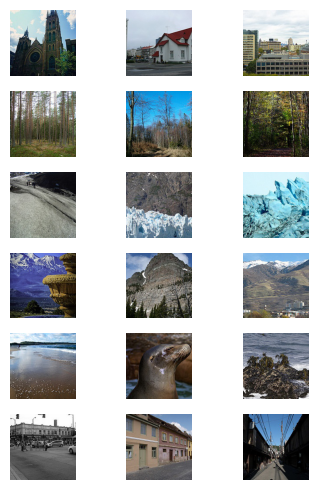

In [6]:
def show_random_images(data_dir, classes, num_per_class=3):
    fig, axes = plt.subplots(len(classes), num_per_class, figsize=(4, 5))

    for i, class_name in enumerate(classes):
        class_path = data_dir / class_name
        all_images = os.listdir(class_path)
        random_images = random.sample(all_images, num_per_class)

        for j, img_name in enumerate(random_images):
            img_path = class_path / img_name
            img = Image.open(img_path)

            axes[i, j].imshow(img)
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

show_random_images(data_dir, classes, num_per_class=3)

In [16]:
def check_image_sizes(data_dir, classes, num_samples=50):
    sizes = []

    for class_name in classes:
        class_path = data_dir / class_name
        images = os.listdir(class_path)[:num_samples]

        for img_name in images:
            img_path = class_path / img_name
            img = Image.open(img_path)
            sizes.append(img.size)

    widths = [s[0] for s in sizes]
    heights = [s[1] for s in sizes]

    print(f"Width  - Min: {min(widths)}, Max: {max(widths)}, Avg: {sum(widths)//len(widths)}")
    print(f"Height - Min: {min(heights)}, Max: {max(heights)}, Avg: {sum(heights)//len(heights)}")

    unique_sizes = set(sizes)
    print(f"\nUnique sizes found: {len(unique_sizes)}")

check_image_sizes(data_dir, classes, num_samples=50)

Width  - Min: 150, Max: 150, Avg: 150
Height - Min: 110, Max: 150, Avg: 149

Unique sizes found: 3


Training set: 14034 images
Test set: 3000 images

Ratio: 4.68 : 1


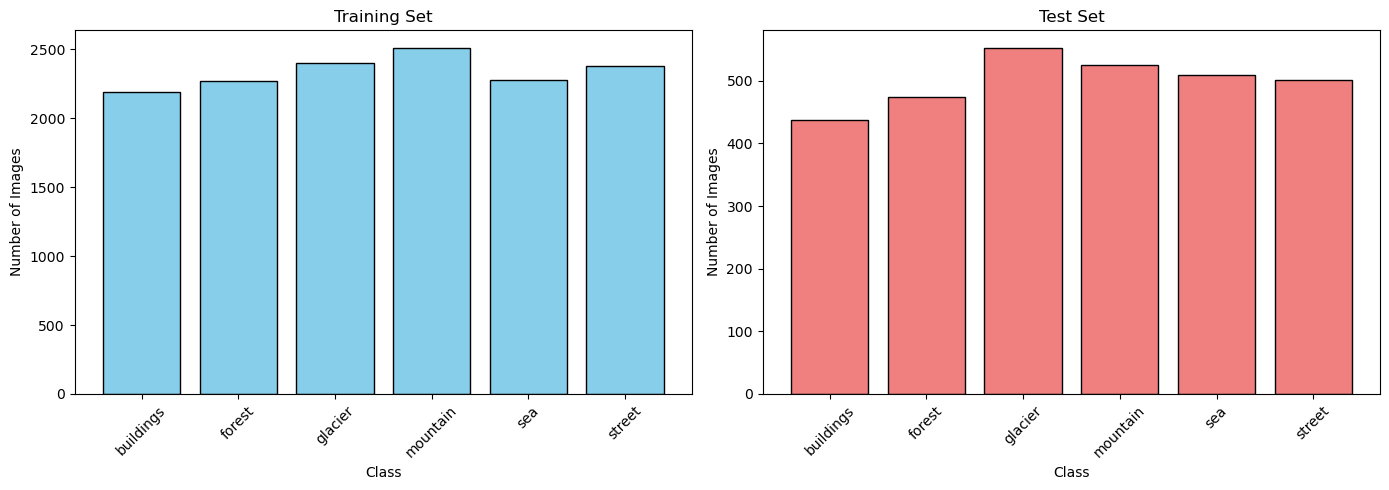

In [20]:
test_dir = Path('../dataSet/archive/seg_test/seg_test')
test_counts = {}
for class_name in classes:
    class_path = test_dir / class_name
    num_images = len(os.listdir(class_path))
    test_counts[class_name] = num_images

total_test = sum(test_counts.values())

print(f"Training set: {total_train} images")
print(f"Test set: {total_test} images")
print(f"\nRatio: {total_train / total_test:.2f} : 1")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(train_counts.keys(), train_counts.values(), color='skyblue', edgecolor='black')
ax1.set_title('Training Set')
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Images')
ax1.tick_params(axis='x', rotation=45)

ax2.bar(test_counts.keys(), test_counts.values(), color='lightcoral', edgecolor='black')
ax2.set_title('Test Set')
ax2.set_xlabel('Class')
ax2.set_ylabel('Number of Images')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()